In [75]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

In [76]:
# Plot
plot_directory = 'result/plot_set'
power_profile_directory = 'result/Dict-Per-Real-Second-Throughput-960.json'

In [77]:
colors = [
	'#e6194B',
	# '#f58231',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
]

In [78]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [79]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [80]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [81]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [82]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [83]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [84]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [85]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [86]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [87]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [88]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

# Dataset

In [89]:
OMV_FEATURE_INDEX = [5, 6]
INITIAL_FPS = '30'
RESAMPLE_RATE = 2
TARGET_ACCURACY = 0.9
SAFEGUARD = 1

PERIOD = ['Day', 'Afternoon', 'Night']
BASE_PERIOD_INDEX = 0
VIDEO_PREFIX = 'Scene-1-'
TEST_SIZE = 0.9
CLASS_INDEX = '2'

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [91]:
def transpose_array(arr):
	# Transpose the input array using zip and map it back to a list
	return [list(row) for row in zip(*arr)]

In [92]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [93]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [94]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			fps = fpss[k]

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			# outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			# omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			# acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

In [95]:
dataset

{'Scene-1-Afternoon': {'1': {'y_all': [0.8070175438596492,
    0.8929219600725952,
    0.9292543021032504,
    0.9333333333333333,
    0.9619238476953909,
    0.9244935543278083,
    0.8315789473684211,
    0.7086614173228347,
    0.7897435897435896,
    0.7073791348600509,
    0.6532951289398281,
    0.6376811594202899,
    0.6594982078853047,
    0.6826347305389222,
    0.7736625514403294,
    0.9045226130653266,
    0.6346153846153846,
    0.9944134078212289,
    0.8653846153846154,
    0.8571428571428572,
    0.7768595041322315,
    0.7966804979253111,
    0.8738738738738739,
    0.9424083769633508,
    0.8653846153846154,
    0.7037037037037037,
    0.5828571428571429,
    0.5878962536023055,
    0.6934306569343065,
    0.7030716723549488,
    0.7211895910780669,
    0.5485436893203883,
    0.5250596658711217,
    0.5777777777777777,
    0.5478036175710594,
    0.622356495468278,
    0.7509025270758123,
    0.8487394957983194,
    0.8780487804878049,
    0.7863247863247863,
    0.

# Train

In [96]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [97]:
prediction_models = {}
for fps in fpss:
	prediction_models[fps] = LinearRegression() # Linear Regression

base_video_name = f'{VIDEO_PREFIX}{PERIOD[BASE_PERIOD_INDEX]}'
for fps in fpss:
	x_base = dataset[base_video_name][fps]['x_all']
	y_base = dataset[base_video_name][fps]['y_all']

	x_base_train, x_base_test, y_base_train, y_base_test = my_train_test_split(x_base, y_base, TEST_SIZE)
			
	prediction_models[fps].fit(x_base_train, y_base_train)

# Test

In [98]:
def estimate_best_fps_v1(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	for i in range(len(fpss)):
		if accuracy_vector[i] >= target_accuracy:
			return fpss[min(i + safeguard, len(fpss)-1)]

	return fpss[-1]

In [99]:
def estimate_best_fps_v2(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i

	return fpss[min(min_idx + safeguard, len(fpss) - 1)]

In [100]:
def extract_metric_list(metric_list, fpss, feature='F1'):
	result_column = {}
	
	for fps in fpss: 
		result_column[fps] = [clip_metric['metric'][fps][feature] for clip_metric in metric_list]
	
	return result_column

In [101]:
def find_max_index(string_list):
	# Convert each element to integer
	int_list = [int(element) for element in string_list]
	
	# Find index of maximum integer value
	max_index, max_value = max(enumerate(int_list), key=lambda x: x[1])
	
	return max_value

def extract_cheapest_fps(accuracy_dict, fpss, threshold=0.75):
	max_fps = find_max_index(fpss)
	
	cheapest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = max_fps
		for fps in fpss:
			if accuracy_dict[fps][i] >= threshold and int(fps) < int(curr_fps):
				curr_fps = fps
		
		cheapest_fpss.append(int(curr_fps))
	
	return cheapest_fpss

In [102]:
def extract_nearest_fps(accuracy_dict, fpss, threshold=0.75):
	nearest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = fpss[0]
		for fps in fpss:
			if abs(accuracy_dict[fps][i] - threshold) < abs(accuracy_dict[curr_fps][i] - threshold):
				curr_fps = fps
		
		nearest_fpss.append(int(curr_fps))
	
	return nearest_fpss

In [103]:
def plot_mutiple_lines(xs, yss, x_label, y_label, y_legends, title, fig_size, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=fig_size)

	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], label=y_legends[i])

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [104]:
p = 2

In [105]:
period_video_name = f'{VIDEO_PREFIX}{PERIOD[p]}'
test_length = len(dataset[period_video_name]['30']['x_all'])
if p == BASE_PERIOD_INDEX:
	split_point = int(test_length * (1-TEST_SIZE))
	test_range = (split_point, test_length)
else:
	test_range = (0, test_length)

In [106]:
selected_fps_list = []
last_fps = INITIAL_FPS
for i in range(test_range[0], test_range[1]):
	if i % RESAMPLE_RATE != 0:
		selected_fps_list.append(last_fps) 
		continue

	clip_omv_of_fps = dataset[period_video_name][last_fps]['x_all'][i]
	suggested_fps = estimate_best_fps_v2(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, SAFEGUARD)

	last_fps = suggested_fps
	selected_fps_list.append(last_fps)
selected_fps_list = [int(x) for x in selected_fps_list]

In [107]:
accuracy_result = load_json_file(os.path.join(plot_directory, period_video_name + "_Accuracy_Result.json"))

accuracy = extract_metric_list(accuracy_result[CLASS_INDEX], fpss)
nearest_fps_list = extract_nearest_fps(accuracy, fpss, TARGET_ACCURACY)
nearest_fps_list = nearest_fps_list[test_range[0] : test_range[1]]

In [108]:
selected_accuracy_list = []
for i in range(test_range[0], test_range[1]):
	selected_throughput = str(selected_fps_list[i-test_range[0]])
	selected_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][selected_throughput]['F1']
	selected_accuracy_list.append(selected_accuracy)

In [109]:
nearest_accuracy_list = []
for i in range(test_range[0], test_range[1]):
	nearest_throughput = str(nearest_fps_list[i-test_range[0]])
	nearest_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][nearest_throughput]['F1']
	nearest_accuracy_list.append(nearest_accuracy)

In [110]:
power_profile = load_json_file(os.path.join(power_profile_directory))
max_power = power_profile[str(max([int(k) for k in list(power_profile.keys())]))]

selected_power_list = []
for st in selected_fps_list:
	if str(st) in power_profile:
		selected_power_list.append(power_profile[str(st)])
	else:
		selected_power_list.append(max_power)

nearest_power_list = []
for nt in nearest_fps_list:
	if str(nt) in power_profile:
		nearest_power_list.append(power_profile[str(nt)])
	else:
		nearest_power_list.append(max_power)

Average Selected F1 Accuracy: 0.8471922561617277
Average Nearest F1 Accuracy: 0.9035189973998607
Average Selected Power: 4.513007893301192
Average Nearest Power: 4.899375304629417


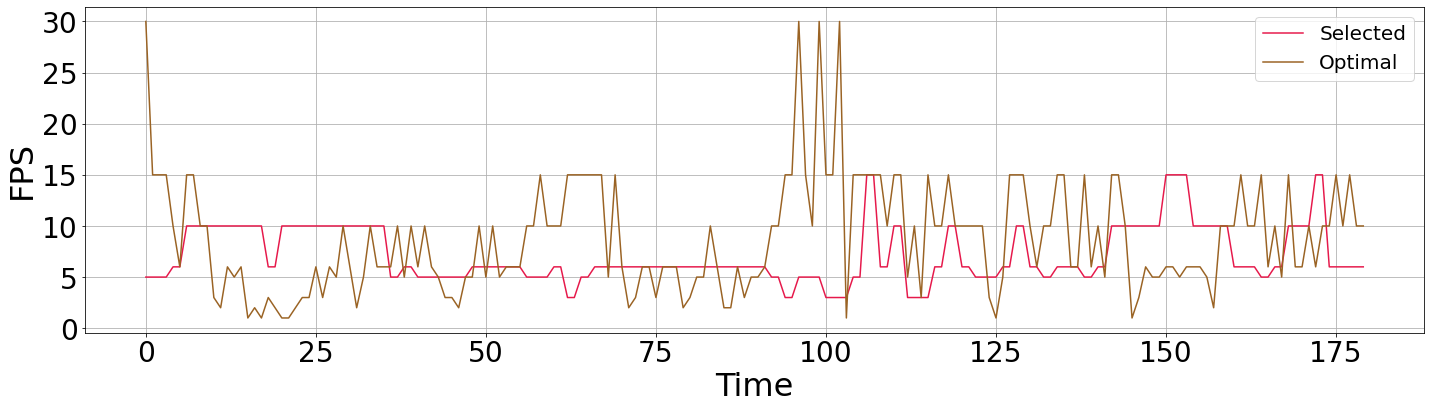

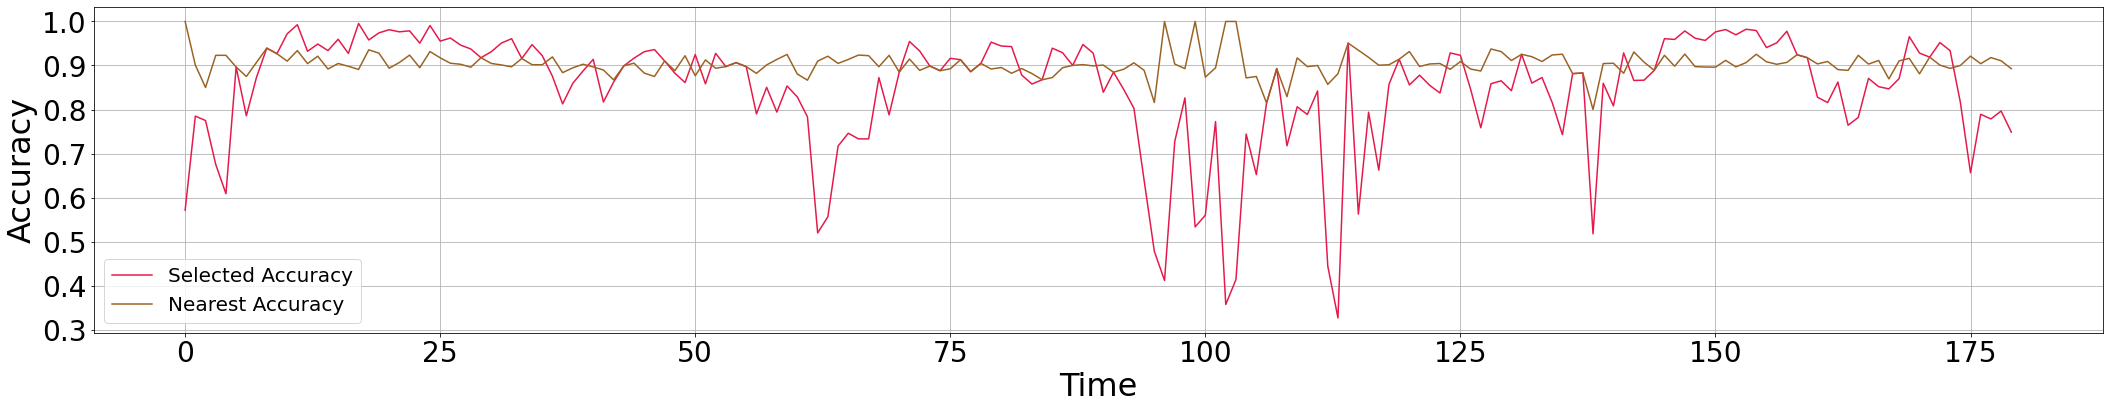

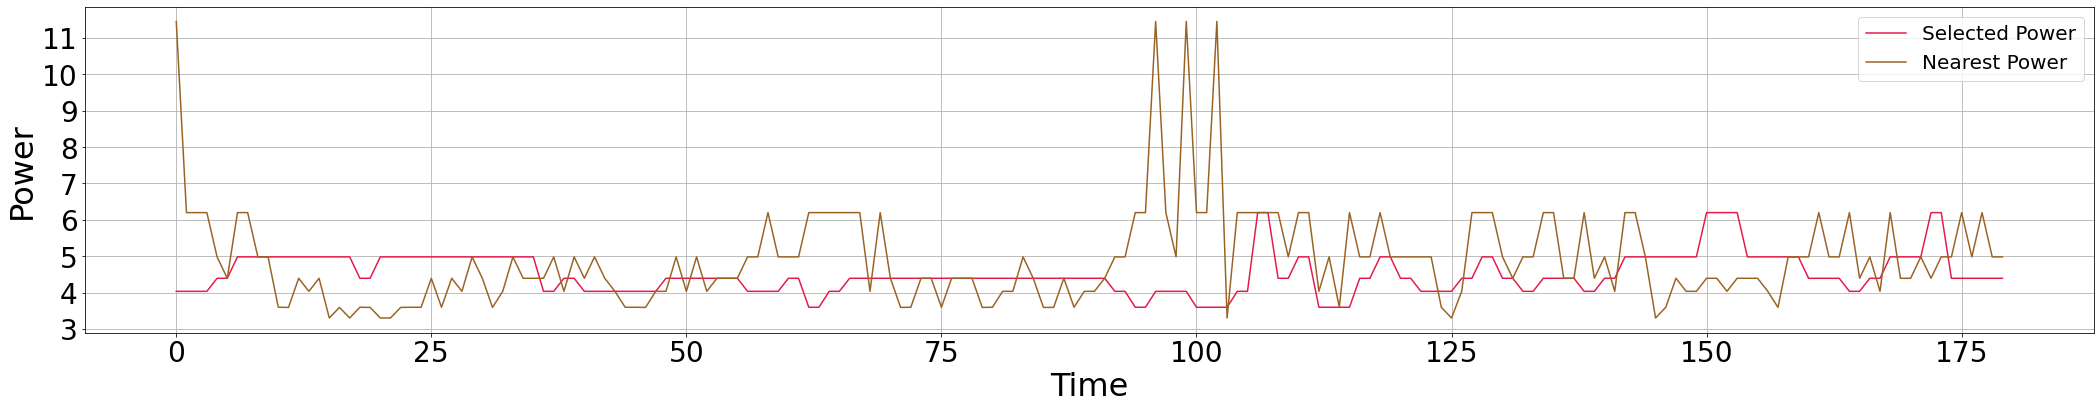

In [111]:
time = range(test_range[0], test_range[1])
print(f'Average Selected F1 Accuracy: {np.mean(np.array(selected_accuracy_list))}')
print(f'Average Nearest F1 Accuracy: {np.mean(np.array(nearest_accuracy_list))}')
print(f'Average Selected Power: {np.mean(np.array(selected_power_list))}')
print(f'Average Nearest Power: {np.mean(np.array(nearest_power_list))}')

plot_mutiple_lines(time, [selected_fps_list, nearest_fps_list], 'Time', 'FPS', ['Selected', 'Optimal'], '', (24, 6))
plot_mutiple_lines(time, [selected_accuracy_list, nearest_accuracy_list], 'Time', 'Accuracy', ['Selected Accuracy', 'Nearest Accuracy'], '', (36, 6))
plot_mutiple_lines(time, [selected_power_list, nearest_power_list], 'Time', 'Power', ['Selected Power', 'Nearest Power'], '', (36, 6))